# Hot-Dry and Hot-Wet Compound Events Calculation

Before you start running the code, it's important to select the kernel. To do this, click on Select Kernek in the upper left corner, choose Jupyter Kernel and then the R (compound) kernel.

In [1]:
library(loadeR)
library(transformeR)
library(visualizeR)

Loading required package: rJava



Loading required package: loadeR.java

Java version 23x amd64 by N/A detected

The maximum JVM heap space available is: 2.00 GB

NetCDF Java Library Version: 5.9.1.1 (Built-On: 2025-09-16T11:37:12-0600) loaded and ready

You can manually set the NetCDF Java Library version before loading the package:
options(loadeR.java_forced_version = "X.Y.Z")
library(loadeR.java)

netCDF-Java CLASSPATH from env LOADER_JAVA_CLASSPATH + bundled java package directory: /opt/conda/envs/compound/lib/java/toolsUI.jar:/opt/conda/envs/compound/lib/R/library/loadeR.java/java:/opt/conda/envs/compound/lib/R/library/loadeR.java/java/netcdfAll-4.6.0-SNAPSHOT.jar

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.4 (2025-08-07) is loaded

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.5 (2026-01-21) is loaded

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



In [2]:
df <- read.csv("data_inventory.csv")
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-5KM-regular_Iberia_day,observations,opendap,AEMET-5KM-regular,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-5KM-regular/Iberia/day/AEMET-5KM-regular_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-5KM-regular.dic
2,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
3,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v1_Canarias_day,observations,opendap,PTI-grid-v1,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v1/Canarias/day/PTI-grid-v1_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


In [3]:
# In this example, the ERA5-Land reanalysis dataset will be loaded.
subset.pi <- subset(df, dataset == "ERA5-Land_Iberia_day")
lon.pi <- as.character(subset.pi$endpoint)
# Doing a data Inventory allow as to see what variables the dataset has,
# the years, the latitude and longitude and the units of each variable.
str(dataInventory(lon.pi))

[2026-03-18 10:40:02] Doing inventory ...

[2026-03-18 10:40:02] Opening dataset...

[2026-03-18 10:40:06] The dataset was successfuly opened

[2026-03-18 10:40:06] Retrieving info for 'sp' (6 vars remaining)

[2026-03-18 10:40:06] Retrieving info for 'pr' (5 vars remaining)

[2026-03-18 10:40:06] Retrieving info for 'tasmax' (4 vars remaining)

[2026-03-18 10:40:06] Retrieving info for 'wss' (3 vars remaining)

[2026-03-18 10:40:06] Retrieving info for 'tas' (2 vars remaining)

[2026-03-18 10:40:06] Retrieving info for 'tdps' (1 vars remaining)

[2026-03-18 10:40:06] Retrieving info for 'tasmin' (0 vars remaining)

[2026-03-18 10:40:06] Done.



List of 7
 $ sp    :List of 7
  ..$ Description: chr "Surface pressure"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 26298 101 161
  ..$ Units      : chr "Pa"
  ..$ DataSizeMb : num 1711
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time     :List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1950-01-01 00:00:00"
  .. .. ..$ Date_range: chr "1950-01-01T00:00:00Z - 2021-12-31T00:00:00Z"
  .. ..$ latitude :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:101] 44 43.9 43.8 43.7 43.6 ...
  .. .. ..$ Shape      : int 101
  .. .. ..$ Coordinates: chr "latitude"
  .. ..$ longitude:List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:161] -10 -9.9 -9.8 -9.7 -9.6 ...
  .. .. ..$ Shape      : int 161
  .. .. ..$ Coordinates: chr "longitude"
 $ pr    :Li

In [4]:
# We select a 20-year period
years <- 1986:2005

# Adjusting lat and lon to northeast of Spain
latitude <- c(39.8, 43)
longitude <- c(-2.3, 3.6)
year.range <- paste0(min(years), "-", max(years))

In [5]:
# Load the variables. We need maximum temperature (tasmax) and precipitation (pr) to compute the indices.   
tasmax <- loadGridData(dataset=lon.pi, var ="tasmax", years = years, latLim = latitude, lonLim = longitude)
tasmax <- gridArithmetics(tasmax, 273.15, operator="-")  # Conversion to °C

pr <- loadGridData(dataset=lon.pi, var ="pr", years = years, latLim = latitude, lonLim = longitude)
pr <- gridArithmetics(pr, 1000, operator="*")  # Conversion to mm/day


[2026-03-18 10:40:13] Opening dataset...

[2026-03-18 10:40:14] The dataset was successfuly opened

[2026-03-18 10:40:14] Defining geo-location parameters

[2026-03-18 10:40:14] Defining time selection parameters

[2026-03-18 10:40:14] Retrieving data subset ...

[2026-03-18 10:40:23] Done

[2026-03-18 10:40:26] Opening dataset...

[2026-03-18 10:40:27] The dataset was successfuly opened

[2026-03-18 10:40:27] Defining geo-location parameters

[2026-03-18 10:40:27] Defining time selection parameters

[2026-03-18 10:40:27] Retrieving data subset ...

[2026-03-18 10:40:35] Done



In [6]:
# If pr < 1 mm/day, it is considered a day without precipitation from a climatological perspective, so a value of 0 is assigned.
pr$Data[pr$Data < 1] <- 0

In [7]:
# We create a earth mask
mask <- climatology(tasmax)
mask$Data[!is.na(mask$Data)] <- 1

[2026-03-18 10:40:45] - Computing climatology...

[2026-03-18 10:40:45] - Done.



In [8]:
# Function to get the months from the mobile window
moving.window <- function(month) {
  months <- c((month-1)%%12, month%%12, (month+1)%%12)  # Previous, current, and next month
  months[months == 0] <- 12  # Corrects December (when (month-1)%%12 gives 0)
  return(sort(months))
}

tmax.vm <- list()

# We convert the diary data of tasmax in a estational cicle
for(i in 1:12){
  tmax.month <- subsetGrid(tasmax, season=moving.window(i))
  tmax.month <- aggregateGrid(grid = tmax.month, aggr.y = list(FUN = "mean", na.rm = FALSE))
  tmax.clim <- climatology(tmax.month)
  tmax.vm[[i]] <- tmax.clim
}
tmax.estational.cicle <- do.call(bindGrid, c(tmax.vm, list(dimension = "time")))

[2026-03-18 10:40:47] Performing annual aggregation...

[2026-03-18 10:40:48] Done.

[2026-03-18 10:40:48] - Computing climatology...

[2026-03-18 10:40:48] - Done.

[2026-03-18 10:40:48] Performing annual aggregation...

[2026-03-18 10:40:49] Done.

[2026-03-18 10:40:49] - Computing climatology...

[2026-03-18 10:40:49] - Done.

[2026-03-18 10:40:49] Performing annual aggregation...

[2026-03-18 10:40:50] Done.

[2026-03-18 10:40:50] - Computing climatology...

[2026-03-18 10:40:50] - Done.

[2026-03-18 10:40:50] Performing annual aggregation...

[2026-03-18 10:40:51] Done.

[2026-03-18 10:40:51] - Computing climatology...

[2026-03-18 10:40:51] - Done.

[2026-03-18 10:40:51] Performing annual aggregation...

[2026-03-18 10:40:51] Done.

[2026-03-18 10:40:51] - Computing climatology...

[2026-03-18 10:40:51] - Done.

[2026-03-18 10:40:51] Performing annual aggregation...

[2026-03-18 10:40:52] Done.

[2026-03-18 10:40:52] - Computing climatology...

[2026-03-18 10:40:52] - Done.

[202

In [9]:
source("functions/fun.hottest.season.R")
hottest.season <- fun.hottest.season(tmax.estational.cicle)

In [10]:
str(hottest.season)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "tasmax"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "daily maximum temperature"
  ..- attr(*, "units")= chr "K"
  ..- attr(*, "longname")= chr "tasmax"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
  ..- attr(*, "subset")= chr "lon"
  ..- attr(*, "annual_agg_cellfun")= chr "mean"
 $ Data    : num [1:3, 1:33, 1:60] 7 8 9 7 8 9 7 8 9 7 ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:60] -2.3 -2.2 -2.1 -2 -1.9 ...
  ..$ y: num [1:33] 39.8 39.9 40 40.1 40.2 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.1
  ..- attr(*, "resY")= num 0.1
 $ Dates   :List of 2
  ..$ start: chr [1:12] "1986-01-01 00:00:00 GMT" "1986-01-01 00:00:00 GMT" "1986-01-01 00:00:00 GMT" "1986-02-01 00:00:00 GMT" ...
  ..$ end  : ch

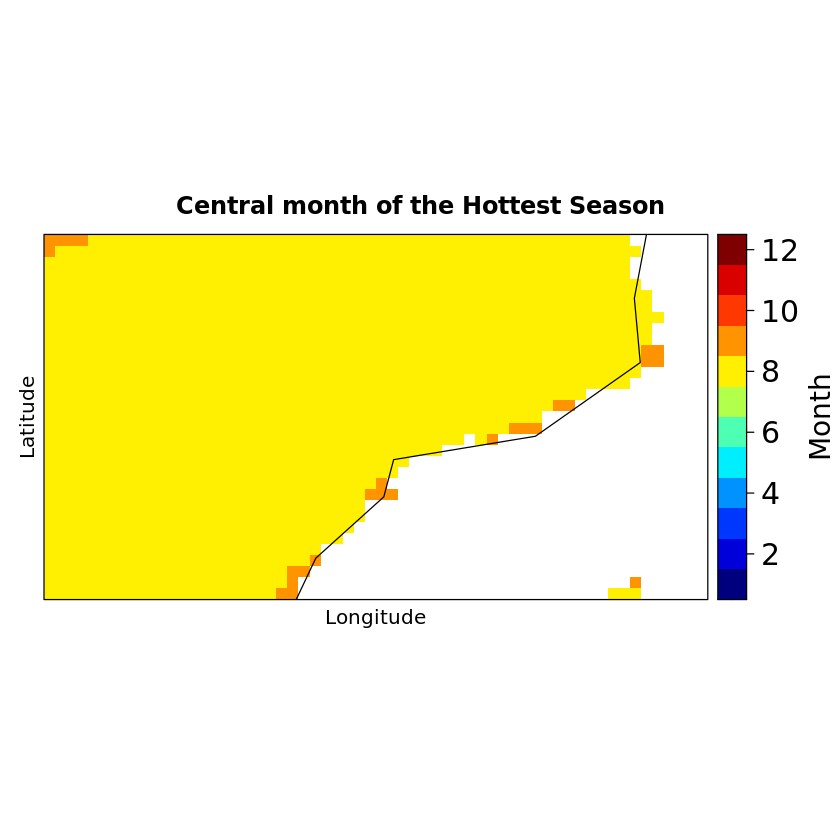

In [11]:

hs <- hottest.season
hs$Data <- hottest.season$Data[2,,]
attr(hs$Data, "dimensions") <- c("lat", "lon")

spatialPlot(hs, backdrop.theme = "coastline", 
            main=paste0("Central month of the Hottest Season"), 
            color.theme="jet.colors", set.min=0.5, set.max=12.5, at=seq(0.5,12.5,1),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Month", cex = 1.4),
                            labels = list(cex = 1.5)))

In [12]:
# Processing data 
source("functions/fun.transform.data.R")
pr.tf <- transform.data(pr, hottest.season)
tmax.tf <- transform.data(tasmax, hottest.season)
print("Transformed data: Done")

[1] "Transformed data: Done"


In [13]:
source("functions/fun.intensity.hw.hd_90_95_100.R")
intensity <- fun.intensity(pr.obs=pr.tf, tmax.obs=tmax.tf, tmax.daily=tmax.tf)

[2026-03-18 10:44:56] - Computing climatology...

[2026-03-18 10:44:57] - Done.

[2026-03-18 10:44:57] - Computing climatology...

[2026-03-18 10:44:57] - Done.



[1] "i=  1"
[1] "i=  2"
[1] "i=  3"
[1] "i=  4"
[1] "i=  5"
[1] "i=  6"
[1] "i=  7"
[1] "i=  8"
[1] "i=  9"
[1] "i=  10"
[1] "i=  11"
[1] "i=  12"
[1] "i=  13"
[1] "i=  14"
[1] "i=  15"
[1] "i=  16"
[1] "i=  17"
[1] "i=  18"
[1] "i=  19"
[1] "i=  20"
[1] "i=  21"
[1] "i=  22"
[1] "i=  23"
[1] "i=  24"
[1] "i=  25"
[1] "i=  26"
[1] "i=  27"
[1] "i=  28"
[1] "i=  29"
[1] "i=  30"
[1] "i=  31"
[1] "i=  32"
[1] "i=  33"


In [14]:
source("functions/fun.categories.intensity.mean.hw.hd.R")
categories <- fun.categories(intensity)


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 10:46:44] - Done.

[2026-03-18 10:46:44] - Computing climatology...

[2026-03-18 1

In [15]:
c1 <- gridArithmetics(categories$c1, mask, operator="*")
c2 <- gridArithmetics(categories$c2, mask, operator="*")
c3 <- gridArithmetics(categories$c3, mask, operator="*")
c4 <- gridArithmetics(categories$c4, mask, operator="*")

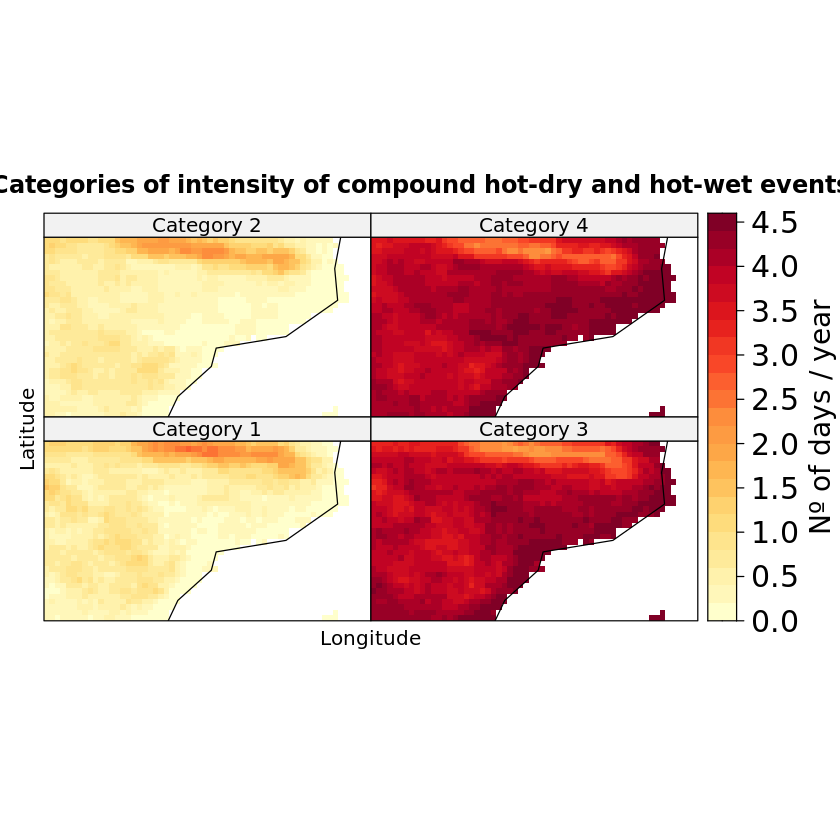

In [16]:
spatialPlot(makeMultiGrid(c2, c4, c1, c3), 
            backdrop.theme = "coastline", 
            main=paste0("Categories of intensity of compound hot-dry and hot-wet events"), 
            as.table=TRUE, names.attr=c("Category 2", "Category 4", "Category 1", "Category 3"),
            color.theme="YlOrRd", set.min=0, set.max=4.6, at=seq(0,4.6,0.2),
            xlab="Longitude", ylab="Latitude",
            colorkey = list(space = "right",
                            title = list("Nº of days / year", cex = 1.4),
                            labels = list(cex = 1.5)))

In [ ]:
source("functions/fun.duration.hw.hd.R")
duration <- d.int(intensity)

In [ ]:
saveRDS(duration, file = "save.data/duration.era5.land.rds", compress = "xz")